
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [2]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2


In [3]:
sales_df.to_csv("urbancart_sales.csv", index=False)
print("Saved urbancart_sales.csv with", len(sales_df), "rows")

Saved urbancart_sales.csv with 1440 rows


**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_

I would use numeric or categorical fields such as `unit_price`, `units_sold`, `month`, `region`, `category`, and `avg_rating` as filters. I would link views using shared identifiers such as `store_id`, `product`, `category`, and `month`, so a selection in one view can highlight the same records elsewhere.


## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


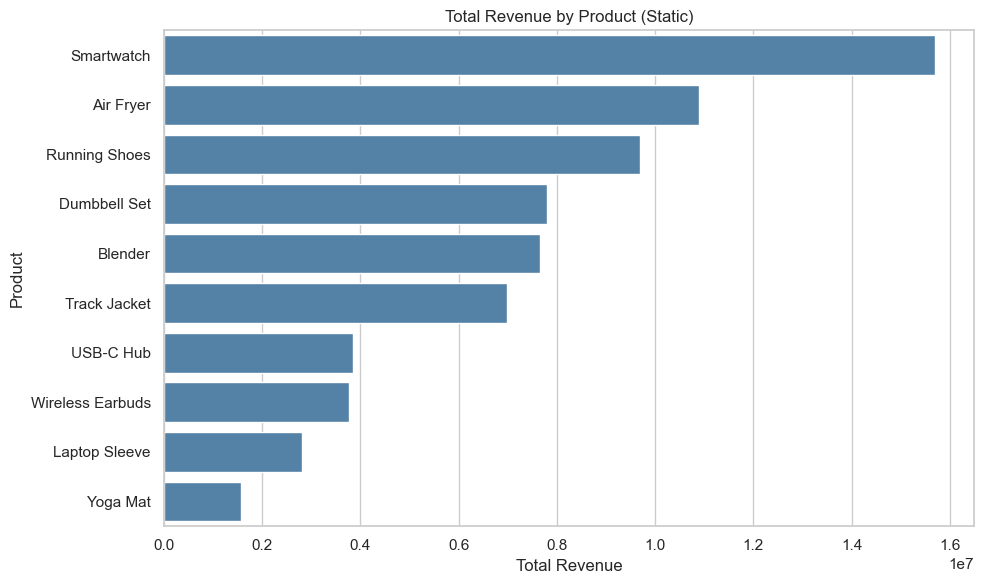

In [4]:
# --- 1a. STATIC chart ---
revenue_by_product = sales_df.groupby("product").revenue.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_product.values, y=revenue_by_product.index, orient="h", color="steelblue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Total Revenue by Product (Static)")
plt.tight_layout()
plt.show()

In [5]:
# --- 1b. INTERACTIVE chart ---
revenue_by_product_cat = (
    sales_df.groupby(["product", "category"]).revenue.sum().reset_index()
    .sort_values("revenue", ascending=False)
)

fig = px.bar(
    revenue_by_product_cat,
    x="product", y="revenue", color="category",
    hover_data={"category": True, "revenue": ":,.0f"},
    title="Total Revenue by Product (Interactive)",
)
fig.show()

**Your 1-2 sentence answer:**

The interactive Plotly version wins for this request because the manager needs exact values on demand, not just a headline comparison. Hover details provide that precision with low implementation and interaction cost while preserving the overall data story.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [3]:
price_slider = widgets.FloatRangeSlider(
    value=[sales_df.unit_price.min(), sales_df.unit_price.max()],
    min=sales_df.unit_price.min(), max=sales_df.unit_price.max(),
    step=50, description="Unit price:",
)

units_slider = widgets.FloatRangeSlider(
    value=[sales_df.units_sold.min(), sales_df.units_sold.max()],
    min=sales_df.units_sold.min(), max=sales_df.units_sold.max(),
    step=1, description="Units sold:",
)

def dynamic_filter(price_range, units_range):
    mask = (
        sales_df.unit_price.between(price_range[0], price_range[1])
        & sales_df.units_sold.between(units_range[0], units_range[1])
    )
    filtered = sales_df[mask]
    print(f"{len(filtered)} / {len(sales_df)} rows match")

    plt.figure(figsize=(7, 5))
    plt.scatter(sales_df.unit_price, sales_df.units_sold, color="lightgray", label="All rows")
    plt.scatter(filtered.unit_price, filtered.units_sold, color="crimson", label="Matching rows")
    plt.xlabel("Unit Price"); plt.ylabel("Units Sold")
    plt.title("Dynamic Query: Price vs. Units Sold")
    plt.legend()
    plt.show()

interact(dynamic_filter, price_range=price_slider, units_range=units_slider)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Unit price:', max=4999.0, min=799.0…

<function __main__.dynamic_filter(price_range, units_range)>

**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_

Two sliders could still be useful for the initial filtering, but at roughly 50 times the data size the interaction may become slow and visually crowded. I would add coordinated views with brushing, or use aggregation and overview-plus-detail so managers inspect summaries first and drill into a smaller subset.


## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [4]:
store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # TODO 1: overview bar, selected store highlighted, rest muted [dimmed/desaturated] gray
    colors = ["crimson" if s == selected_store else "lightgray" for s in store_overview.store_id]
    axes[0].bar(store_overview.store_id, store_overview.revenue, color=colors)
    axes[0].set_title("Revenue by Store (Overview)")
    axes[0].set_xlabel("Store"); axes[0].set_ylabel("Revenue")

    # TODO 2: category breakdown for selected store
    cat_data = sales_df[sales_df.store_id == selected_store].groupby("category").revenue.sum()
    axes[1].pie(cat_data.values, labels=cat_data.index, autopct="%1.0f%%")
    axes[1].set_title(f"{selected_store}: Revenue by Category")

    # TODO 3: monthly trend for selected store
    trend = sales_df[sales_df.store_id == selected_store].groupby("month").revenue.sum()
    axes[2].plot(trend.index, trend.values, marker="o", color="crimson")
    axes[2].set_title(f"{selected_store}: Monthly Revenue Trend")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

interact(store_coordinated_view, selected_store=widgets.Dropdown(options=stores["store_id"].tolist()))

interactive(children=(Dropdown(description='selected_store', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06'…

<function __main__.store_coordinated_view(selected_store)>

**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_

The overview bar chart provides context because it keeps all stores visible, while the selected store's category breakdown and monthly trend provide focus. This is related to brushing but not identical: brushing is the selection mechanism that marks linked records, whereas focus and context describe how the display balances detail with the surrounding overview.


## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [8]:
# --- Part A ---
def min_median_ratio(x):
    return x.min() / x.median() if x.median() != 0 else np.nan

anomaly_ranking = (
    sales_df.groupby(["store_id", "product"]).units_sold
    .agg(min_median_ratio)
    .reset_index(name="min_to_median_ratio")
    .sort_values("min_to_median_ratio")
)

print(anomaly_ranking.head(5))

   store_id       product  min_to_median_ratio
25      S03    Smartwatch             0.185714
47      S05     USB-C Hub             0.250000
6       S01  Track Jacket             0.300000
27      S03     USB-C Hub             0.303030
19      S02      Yoga Mat             0.315789


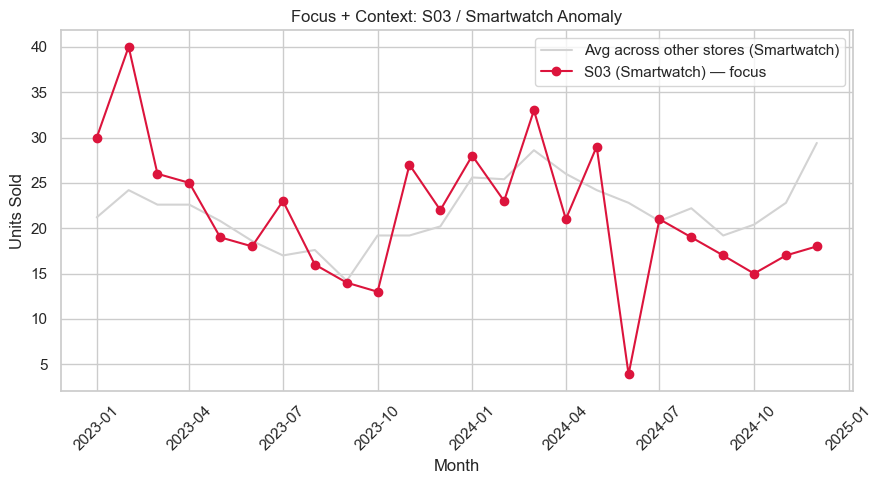

In [9]:
# --- Part B ---
overview_df = sales_df.copy()
overview_df["store_product"] = overview_df.store_id + " — " + overview_df["product"]

fig_overview = px.line(
    overview_df, x="month", y="units_sold", color="store_product",
    hover_data=["store_id", "product"],
    title="Units Sold Over Time — All Store/Product Combinations",
)
fig_overview.show()

top_store, top_product = anomaly_ranking.iloc[0][["store_id", "product"]]

focus = (sales_df[(sales_df.store_id == top_store) & (sales_df["product"] == top_product)]
         .groupby("month").units_sold.sum())
context = (sales_df[(sales_df.store_id != top_store) & (sales_df["product"] == top_product)]
           .groupby("month").units_sold.mean())

plt.figure(figsize=(9, 5))
plt.plot(context.index, context.values, color="lightgray", label=f"Avg across other stores ({top_product})")
plt.plot(focus.index, focus.values, color="crimson", marker="o", label=f"{top_store} ({top_product}) — focus")
plt.title(f"Focus + Context: {top_store} / {top_product} Anomaly")
plt.xlabel("Month"); plt.ylabel("Units Sold")
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()

**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_

I used eye fixation on the overview's unusually low trend and hover to identify its `store_id` and `product`, then used the focused drill-down chart to investigate it while retaining context. Using a cheap tier to spot the issue and a more detailed interaction to explain it is the right call because it minimizes effort while preserving the overview.


## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [10]:
product_summary = sales_df.groupby("product").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    avg_rating=("avg_rating", "mean"),
).reset_index()

product_summary = product_summary.sort_values("revenue", ascending=False)

styled = (
    product_summary.style
    .bar(subset=["revenue"], color="#5fa8d3")
    .bar(subset=["profit"], color="#f4a261")
    .bar(subset=["avg_rating"], color="#90be6d")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Product Performance Summary (sorted by Revenue)")
)
styled

,product,revenue,profit,avg_rating
5,Smartwatch,"15,706,358","3,881,507",4.09
0,Air Fryer,"10,901,274","2,593,731",4.04
4,Running Shoes,"9,688,731","2,303,075",4.10
2,Dumbbell Set,"7,796,880","1,829,127",4.11
1,Blender,"7,648,773","1,860,309",4.04
6,Track Jacket,"6,992,502","1,610,283",4.13
7,USB-C Hub,"3,842,442","907,435",4.09
8,Wireless Earbuds,"3,769,985","890,554",4.09
3,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07


In [11]:
product_summary_by_profit = product_summary.sort_values("profit", ascending=False)

styled_profit = (
    product_summary_by_profit.style
    .bar(subset=["revenue"], color="#5fa8d3")
    .bar(subset=["profit"], color="#f4a261")
    .bar(subset=["avg_rating"], color="#90be6d")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Product Performance Summary (sorted by Profit)")
)
styled_profit

,product,revenue,profit,avg_rating
5,Smartwatch,"15,706,358","3,881,507",4.09
0,Air Fryer,"10,901,274","2,593,731",4.04
4,Running Shoes,"9,688,731","2,303,075",4.10
1,Blender,"7,648,773","1,860,309",4.04
2,Dumbbell Set,"7,796,880","1,829,127",4.11
6,Track Jacket,"6,992,502","1,610,283",4.13
7,USB-C Hub,"3,842,442","907,435",4.09
8,Wireless Earbuds,"3,769,985","890,554",4.09
3,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07


**Your observation (revenue-sorted vs profit-sorted top rows):**

The top rows can change because high revenue does not necessarily mean high profit; profitability also depends on the product's margin. A manager should therefore compare both sorts before deciding which products to promote, stock, or investigate.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


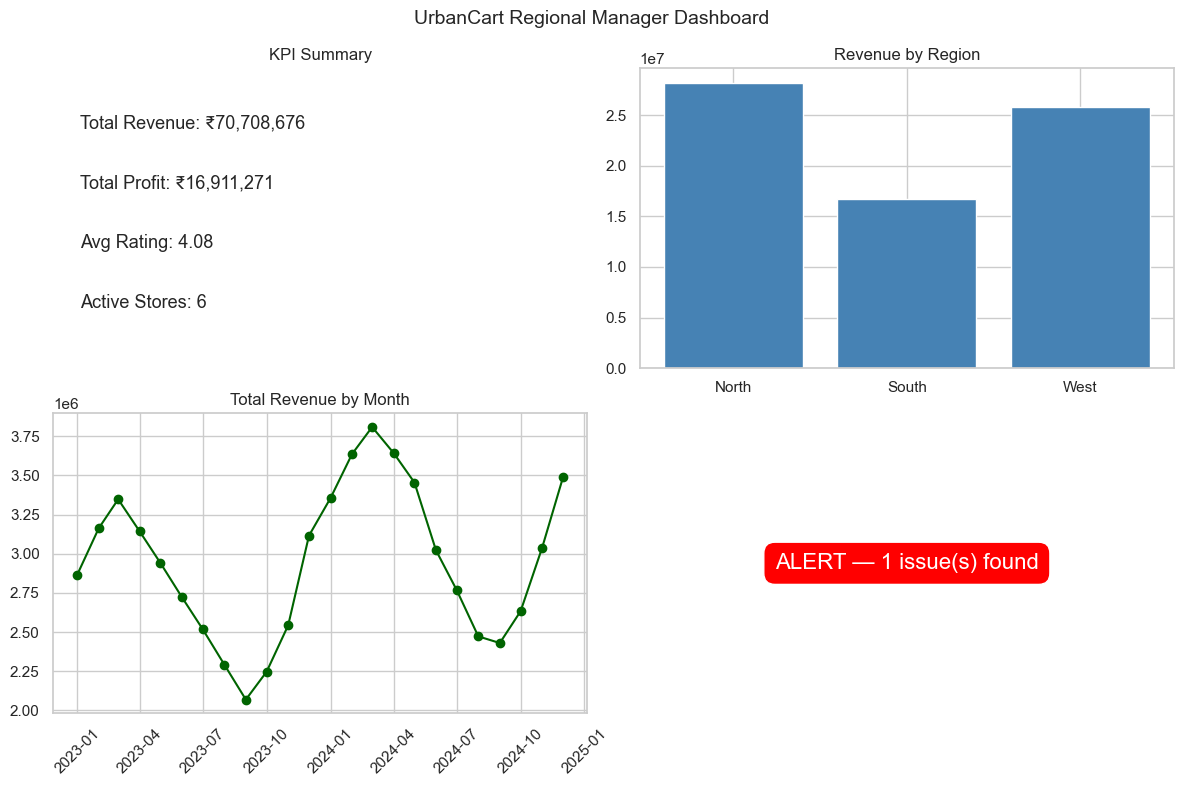

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---
total_revenue = sales_df.revenue.sum()
total_profit = sales_df.profit.sum()
avg_rating_overall = sales_df.avg_rating.mean()
n_active_stores = sales_df.store_id.nunique()

axes[0, 0].axis("off")
axes[0, 0].text(0.05, 0.8, f"Total Revenue: ₹{total_revenue:,.0f}", fontsize=13)
axes[0, 0].text(0.05, 0.6, f"Total Profit: ₹{total_profit:,.0f}", fontsize=13)
axes[0, 0].text(0.05, 0.4, f"Avg Rating: {avg_rating_overall:.2f}", fontsize=13)
axes[0, 0].text(0.05, 0.2, f"Active Stores: {n_active_stores}", fontsize=13)
axes[0, 0].set_title("KPI Summary")

# --- Panel 2: revenue by region (top-right) ---
region_revenue = sales_df.groupby("region").revenue.sum()
axes[0, 1].bar(region_revenue.index, region_revenue.values, color="steelblue")
axes[0, 1].set_title("Revenue by Region")

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
monthly_revenue = sales_df.groupby("month").revenue.sum()
axes[1, 0].plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="darkgreen")
axes[1, 0].set_title("Total Revenue by Month")
axes[1, 0].tick_params(axis="x", rotation=45)

# --- Panel 4: peripheral alert panel (bottom-right) ---
def has_anomaly(x):
    return (x < 0.25 * x.median()).any()

anomalies = sales_df.groupby(["store_id", "product"]).units_sold.apply(has_anomaly)
n_issues = int(anomalies.sum())

axes[1, 1].axis("off")
if n_issues > 0:
    axes[1, 1].text(0.5, 0.5, f"ALERT — {n_issues} issue(s) found", fontsize=16,
                     color="white", ha="center", va="center",
                     bbox=dict(facecolor="red", boxstyle="round,pad=0.5"))
else:
    axes[1, 1].text(0.5, 0.5, "OK", fontsize=16,
                     color="white", ha="center", va="center",
                     bbox=dict(facecolor="green", boxstyle="round,pad=0.5"))

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()

## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
have to think about while building it?
3. If you had to add *one more* interaction technique from the lecture that this activity didn't
cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
retail scenario would it actually be useful, and why?

_Your answers here._

1. Coordinated views with brushing probably save the most time because one store selection updates its category breakdown and monthly trend immediately, avoiding repeated PDF searches and comparisons.
2. Focus plus context drill-down was hardest because the view must make the anomaly prominent without hiding the baseline. That is a trade-off between detail and overview, and between interaction cost and the amount of information shown at once.
3. A magic lens could be useful on the store or product trend overview: moving the lens over a dense cluster could reveal exact units, revenue, margin, and rating details without replacing the full comparison view.